### **Useful Packages**

In [3]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

import pryngles as pr
import geotrans as geo
import geotrans2 as geo2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### **Considering Limb-Darkening**

In order to consider the *Limb-Darkening* effect, we define a scaling factor $\alpha$ for planet area. In this way, we compute the transit depth more accurately

$$\alpha = \frac{I^{(limb)}}{I^{(no-limb)}}$$

**Kepler 51, Limb Coeffs Source:** https://arxiv.org/html/2410.01625v2#abstract

In [ ]:
rhos = np.linspace(-1, 1, 1000) # Projected Distance over Star's Disk

# No Limb-Darkening
I_nlimb = pr.Science.limb_darkening(rhos, cs = [0, 0]) 

# Considering Limb-Darkening
limb_cf = [0.296, 0.4] # https://arxiv.org/html/2410.01625v2#abstract
I_limb = pr.Science.limb_darkening(rhos, cs = limb_cf)

# Scaling Factor
alphas = I_limb/I_nlimb


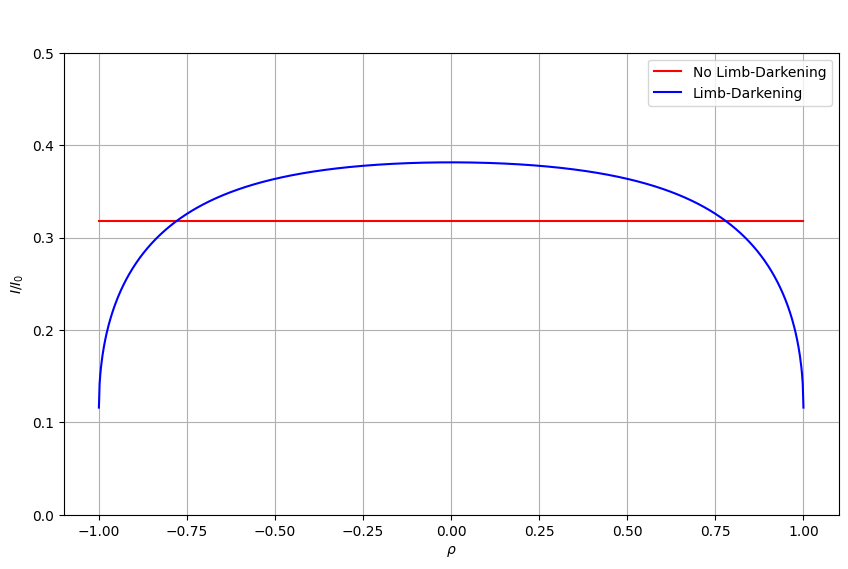

In [ ]:
plt.figure(figsize = (10, 6))

plt.plot(rhos, I_nlimb, label = 'No Limb-Darkening', color = 'red')
plt.plot(rhos, I_limb, label = 'Limb-Darkening', color = 'blue')

plt.title('\n')
plt.xlabel(r'$\rho$')
plt.ylabel(r'$I/I_0$')

plt.legend()
plt.grid()

plt.ylim(0, 0.5)

plt.show()

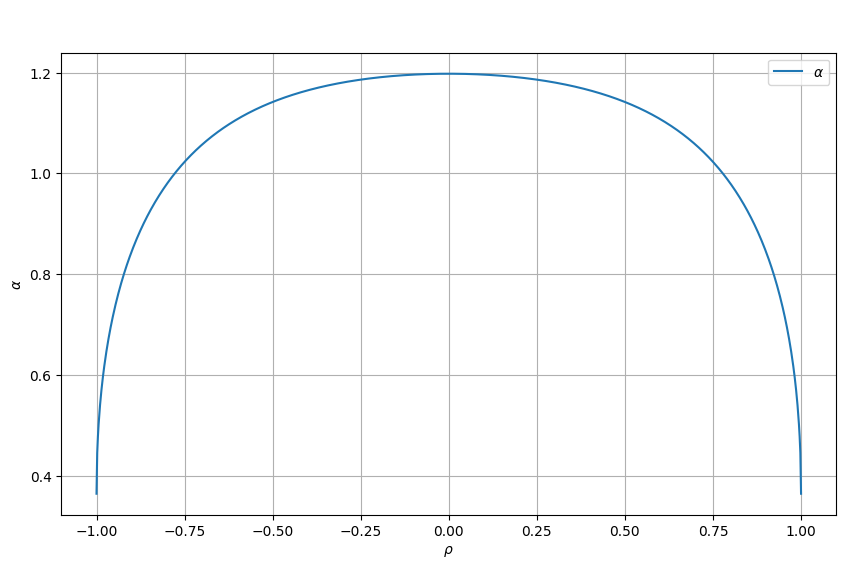

In [ ]:
plt.figure(figsize = (10, 6))

plt.plot(rhos, I_limb/I_nlimb, label = r'$\alpha$')

plt.grid()
plt.legend()

plt.title('\n')
plt.xlabel(r'$\rho$')
plt.ylabel(r'$\alpha$')

plt.show()